## 1. Create data

In [1]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [2]:
len(X), len(y)

(1000, 1000)

In [3]:
X.shape, y.shape

((1000, 2), (1000,))

In [11]:
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],
                    "X2":X[:,1],
                    "label":y})

circles.head(10)

,X1,X2,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0
5,-0.469885,0.708037,1
6,-0.016045,0.805623,1
7,0.759623,0.159526,1
8,-0.175692,-0.799837,1
9,-0.110616,1.042207,0


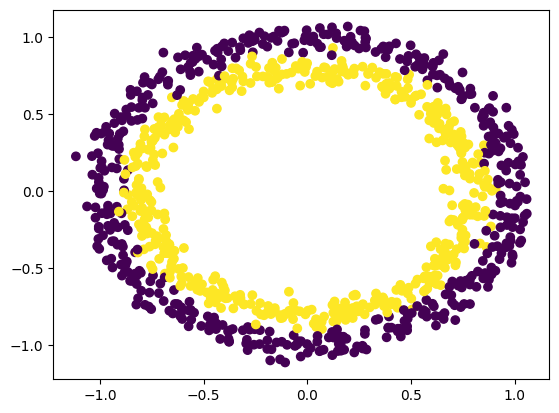

In [13]:
import matplotlib.pyplot as plt
plt.scatter(circles['X1'],
            circles['X2'],
            c=circles['label'])
plt.show()    

### 1.1 Turn data into tesnors

In [15]:
import torch 
torch.__version__

'2.11.0+cpu'

In [16]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7422,  0.2467],
         [-0.7340,  0.1687],
         [-0.8299,  0.2220],
         [-0.4291,  0.6722],
         [ 0.4456, -0.8949]]),
 tensor([1., 1., 1., 1., 0.]))

In [17]:
# Split data into training/test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
                                                    

In [18]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [20]:
type(X_train), type(y_train), type(X_test), type(y_test)

(torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor)

## 2. Building a model

In [21]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [22]:
X_train.shape

torch.Size([800, 2])

In [28]:
class CircleModelV0(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=10)      
        self.layer_2 = nn.Linear(in_features=10, out_features=1)

        # self.two_linear_layer = nn.Sequential(
        #     nn.Linear(in_features=2, out_features=10),
        #     nn.Linear(in_features=10, out_features=1)
        #     )

    def forward(self, x:torch.Tensor):
        z1 = self.layer_1(x)
        z2 = self.relu_2(z1)

        return z2
        # return self.two_linear_layer(x)

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

In [31]:
# Create model above with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Linear(in_features=10, out_features=1)
)
model_0.to(device)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=1, bias=True)
)

In [30]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4565,  0.5684],
                      [-0.2870,  0.6175],
                      [ 0.1471, -0.5665],
                      [ 0.5444,  0.0290],
                      [ 0.0708,  0.0622],
                      [ 0.2924, -0.5226],
                      [ 0.1215,  0.5262],
                      [ 0.6887,  0.6627],
                      [-0.4036, -0.2119],
                      [-0.2006, -0.4680]])),
             ('0.bias',
              tensor([-0.2934,  0.1766,  0.2185,  0.1791,  0.0508, -0.0983,  0.1060,  0.5364,
                      -0.5340, -0.4990])),
             ('1.weight',
              tensor([[-0.1469,  0.2785,  0.2600,  0.0247,  0.2861, -0.3154, -0.1553,  0.2180,
                        0.0337,  0.1865]])),
             ('1.bias', tensor([-0.2136]))])

In [33]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
untrained_preds.shape, y_test.shape

(torch.Size([200, 1]), torch.Size([200]))

In [34]:
untrained_preds[:10]

tensor([[0.2275],
        [0.1910],
        [0.2379],
        [0.2235],
        [0.1194],
        [0.0975],
        [0.0998],
        [0.0780],
        [0.2419],
        [0.1927]])

### 2.1 Setup loss & optimizer

In [35]:
# Setup the loss function 

# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_0.parameters(), 
                                lr=0.1)

In [36]:
# Calculate accuracy 
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 3. Train model

In [42]:
## Eval model 
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.2275],
        [0.1910],
        [0.2379],
        [0.2235],
        [0.1194]])

In [43]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [44]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5566],
        [0.5476],
        [0.5592],
        [0.5556],
        [0.5298]])

* `y_pred_probs` >= 0.5 `y=1` (class 1)

* `y_pred_probs` < 0.5 `y=0` (class 0)


In [48]:
y_preds = torch.round(y_pred_probs)

# In one line
y_predv2 = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(),y_predv2.squeeze()))

tensor([True, True, True, True, True])
